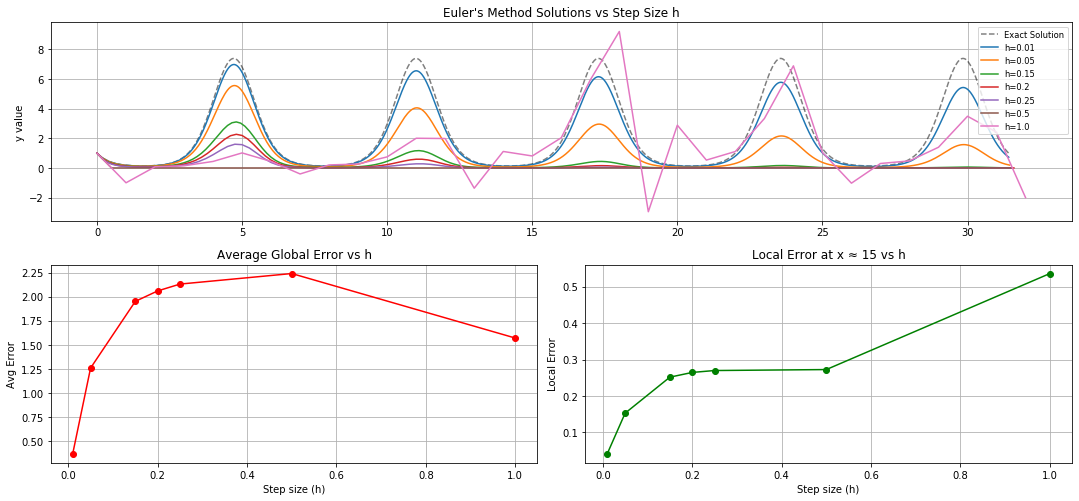

    h |    y(x≈15) |      Exact
--------------------------------
 0.01 |     0.2314 |     0.2724
 0.05 |     0.1199 |     0.2724
 0.15 |     0.0209 |     0.2724
 0.20 |     0.0079 |     0.2724
 0.25 |     0.0027 |     0.2724
 0.50 |     0.0000 |     0.2724
 1.00 |     0.8086 |     0.2724


In [8]:
import numpy as np
import matplotlib.pyplot as plt

f = lambda x, y: -2 * y * np.cos(x)
exact_sol = lambda x: np.exp(-2 * np.sin(x))

x_start, x_end = 0, 10 * np.pi
y0 = 1
h_values = [0.01, 0.05, 0.15, 0.2, 0.25, 0.5, 1.0]

results = {}
avg_errors = []
local_errors_at_15 = []

plt.figure(figsize=(15, 10))

for h in h_values:
    x_vals = np.arange(x_start, x_end + h, h)
    y_vals = np.zeros(len(x_vals))
    y_vals[0] = y0

    for i in range(len(x_vals) - 1):
        y_vals[i+1] = y_vals[i] + h * f(x_vals[i], y_vals[i])
    
    y_exact = exact_sol(x_vals)
    errors = np.abs(y_vals - y_exact)
    
    results[h] = (x_vals, y_vals)
    avg_errors.append(np.mean(errors))
    
    idx_15 = (np.abs(x_vals - 15)).argmin()
    local_errors_at_15.append(errors[idx_15])

plt.subplot(3, 1, 1)
x_fine = np.linspace(x_start, x_end, 1000)
plt.plot(x_fine, exact_sol(x_fine), 'k--', label='Exact Solution', alpha=0.5)
for h in h_values:
    plt.plot(results[h][0], results[h][1], label=f'h={h}')
plt.title("Euler's Method Solutions vs Step Size h")
plt.ylabel("y value")
plt.legend(loc='upper right', fontsize='small')
plt.grid(True)

plt.subplot(3, 2, 3)
plt.plot(h_values, avg_errors, 'o-', color='red')
plt.title("Average Global Error vs h")
plt.xlabel("Step size (h)")
plt.ylabel("Avg Error")
plt.grid(True)

plt.subplot(3, 2, 4)
plt.plot(h_values, local_errors_at_15, 'o-', color='green')
plt.title("Local Error at x ≈ 15 vs h")
plt.xlabel("Step size (h)")
plt.ylabel("Local Error")
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"{'h':>5} | {'y(x≈15)':>10} | {'Exact':>10}")
print("-" * 32)
for h in h_values:
    x_v, y_v = results[h]
    idx = (np.abs(x_v - 15)).argmin()
    print(f"{h:5.2f} | {y_v[idx]:10.4f} | {exact_sol(15):10.4f}") 

As the step size increases, the solution goes further from further from the black line. This is because Euler's method is a first-order approximation, and so the slope is changing rapidly because so. 
Looking at the global error graph, we see that the error grows really fast from 0.01 to 0.2. After step size = 0.5, the error begins to drop. This is because the solution has become so unstable that it doesn't actually follow the function correctly.
Looking at the local error plot, we see that for small values of h, the error increases linearly, and then begins to plateau as h gets bigger. It again begins to increase linearly because of the erratic oscillations seen at the graph above.